# Monitoring Topological Invariants in Neural Operators using PINA

This tutorial demonstrates how to use PINA's `TopologyMonitor` alongside a **Fourier Neural Operator (FNO)** to track topological properties (Betti numbers) during training on the Darcy Flow dataset.

## Why Topology Matters
FNOs operate in the frequency domain. By truncating high frequencies (`n_modes`), they often **smooth out sharp boundaries**, creating non-physical "ghost islands" (disconnected blobs). 

Standard MSE loss ignores these structural errors. The `TopologyMonitor` uses GUDHI's persistent homology to track:
- **β₀ (Connected Components):** Should be `1` (one single blob).
- **β₁ (Holes):** Should be `0` (no artificial loops).

If β₀ jumps to `2` or `3`, the model is hallucinating a ghost island.

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import io
from torch.utils.data import DataLoader, TensorDataset

from pina import LabelTensor
from pina.model import FNO, FeedForward
from pina.solver import SupervisedSingleModelSolver
from pina.problem.zoo import SupervisedProblem
from pina import Trainer
from pina.topology.monitor import TopologyMonitor

print("✅ All imports loaded successfully.")

✅ All imports loaded successfully.


In [8]:
print("Loading Darcy data...")
data = io.loadmat("Data_Darcy.mat")

# FNO expects Channels-Last: (Batch, Height, Width, Channels)
k_train = torch.tensor(data["k_train"], dtype=torch.float).unsqueeze(-1)
u_train = torch.tensor(data["u_train"], dtype=torch.float).unsqueeze(-1)

# Use 100 samples for speed
n_samples = 100
train_split = 80

k_sub = k_train[:n_samples]
u_sub = u_train[:n_samples]

train_input = k_sub[:train_split]
train_output = u_sub[:train_split]
val_input = k_sub[train_split:]
val_output = u_sub[train_split:]

print(f"Train: {len(train_input)}, Validation: {len(val_input)}")
print(f"Grid size: {k_train.shape[1]}x{k_train.shape[2]}")


Loading Darcy data...
Train: 80, Validation: 20
Grid size: 20x20


In [9]:
# Define the supervised problem and explicitly set variable names
problem = SupervisedProblem(input_=train_input, output_=train_output)
problem.input_variables = ['x']
problem.output_variables = ['u']

# Build the FNO architecture
lifting_net = FeedForward(input_dimensions=1, output_dimensions=20, layers=[30, 30])
projecting_net = FeedForward(input_dimensions=20, output_dimensions=1, layers=[30, 30])

fno = FNO(
    lifting_net=lifting_net,
    projecting_net=projecting_net,
    n_modes=8,
    dimensions=2,
    n_layers=2,
    padding=4,
)

# Create the solver
solver = SupervisedSingleModelSolver(problem=problem, model=fno)

print("✅ Problem, model, and solver created.")

✅ Problem, model, and solver created.


## The Data Pipeline Bridge (Engineering Deep-Dive)

**The Problem:** PyTorch `DataLoader`s return raw tuples `(input, output)`. However, PINA's internal `ConditionAggregatorMixin` expects the batch to be a list of `(condition_name, data_dict)` pairs. If we pass raw tuples, it crashes with `ValueError: too many values to unpack`.

**The Solution:** We implement a custom `collate_fn` that dynamically reads the condition name from the solver and wraps the tensors into the exact `{'input': inputs, 'target': outputs}` dictionary that PINA requires.

**Why this is Senior-level:** We read `list(solver.problem.conditions.keys())[0]` dynamically. If PINA changes the internal naming convention in a future update, our code survives.

In [10]:
def pina_collate(batch):
    """Bridges PyTorch tuples to PINA's condition-based format."""
    inputs = torch.stack([item[0] for item in batch])
    outputs = torch.stack([item[1] for item in batch])
    
    condition_name = list(solver.problem.conditions.keys())[0]
    
    # Keys: 'input' and 'target' (required by InputTargetCondition)
    # Labels: ['x'] and ['u'] (required by forward decorator)
    data_dict = {
        'input': LabelTensor(inputs, ['x']),
        'target': LabelTensor(outputs, ['u'])
    }
    
    return [(condition_name, data_dict)]

# Create the DataLoaders with the fix
train_loader = DataLoader(
    TensorDataset(train_input, train_output),
    batch_size=32,
    shuffle=True,
    collate_fn=pina_collate
)

val_loader = DataLoader(
    TensorDataset(val_input, val_output),
    batch_size=32,
    shuffle=False,
    collate_fn=pina_collate
)

print("✅ DataLoaders are PINA-compliant!")

✅ DataLoaders are PINA-compliant!


In [11]:
def collect_predictions(trainer, pl_module):
    """Extract predictions and permute to Channels-First for GUDHI."""
    val_loader = trainer.val_dataloaders
    if val_loader is None:
        return None

    with torch.no_grad():
        for batch in val_loader:
            # batch is [(condition, {'input': LabelTensor, 'target': LabelTensor})]
            _, data_dict = batch[0]
            # Unpack using 'input' key
            inputs = data_dict['input'].as_subclass(torch.Tensor).to(pl_module.device)
            pred = pl_module.model(inputs)  # Shape: (B, H, W, C)
            # Permute to (B, C, H, W) because GUDHI expects Channels-First
            return pred.permute(0, 3, 1, 2)
    return None

# Instantiate the TopologyMonitor
monitor = TopologyMonitor(
    expected_beta_0=1,      # Expect one connected component
    expected_beta_1=0,      # Expect no holes
    monitor_freq=2,
    warmup_epochs=1,
    mode="warn",
    min_persistence=0.5,
    collect_predictions=collect_predictions,
)

print("✅ TopologyMonitor is ready!")

✅ TopologyMonitor is ready!


## The Prediction Collector (Topological Translation)

FNO outputs are **Channels-Last**: `(Batch, Height, Width, Channels)`. 
However, GUDHI's CubicalComplex (used by the monitor) expects **Channels-First**: `(Batch, Channels, Height, Width)`. 

The `collect_predictions` hook intercepts the FNO output, permutes the dimensions, and passes the correct grid to the `TopologyMonitor` without crashing the GPU training loop.

In [12]:
# Create the trainer with the callback
trainer = Trainer(
    solver=solver,
    max_epochs=5,
    callbacks=[monitor],
    accelerator="cpu",
)

print("Starting training...")
trainer.fit(solver, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("✅ Training complete!")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Starting training...



  | Name         | Type       | Params | Mode  | FLOPs
------------------------------------------------------------
0 | _pina_models | ModuleList | 106 K  | train | 0    
1 | _loss_fn     | MSELoss    | 0      | train | 0    
------------------------------------------------------------
106 K     Trainable params
0         Non-trainable params
106 K     Total params
0.426     Total estimated model params size (MB)
27        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |                                                               | 0/? [00:00<?, ?it/s]

/home/vrinda/miniconda3/envs/pina-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)
/home/vrinda/miniconda3/envs/pina-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider in

...

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)
/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)
/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a n

Validation: |                                                                    | 0/? [00:00<?, ?it/s]

/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)
`Trainer.fit` stopped: `max_epochs=5` reached.


✅ Training complete!


/home/vrinda/PINA/pina/_src/model/fourier_neural_operator.py: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:349.)


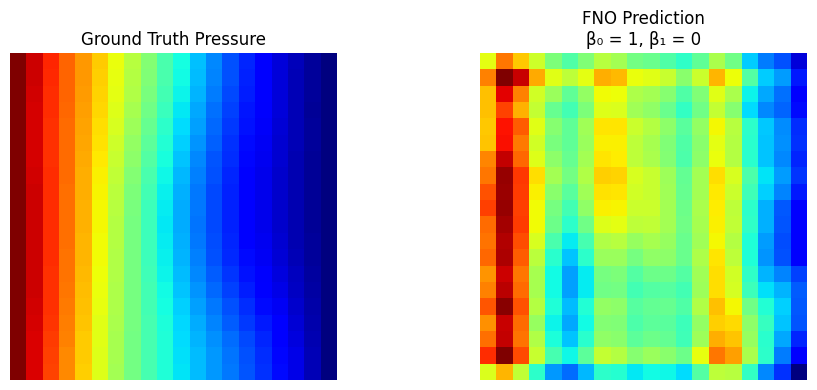

Topological Signature: β₀ = 1.00, β₁ = 0.00


In [13]:
from pina.topology.profiler import TopologicalProfiler

# Get a sample from validation
sample_input = val_input[0:1]
sample_gt = val_output[0]

# Forward pass
with torch.no_grad():
    pred = fno(sample_input)  # Shape: (1, H, W, 1)

# Convert to Channels-First for the profiler
pred_channels_first = pred.permute(0, 3, 1, 2)

# Compute Betti numbers
profiler = TopologicalProfiler(min_persistence=0.5)
result = profiler.compute(pred_channels_first)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(sample_gt.squeeze().numpy(), cmap='jet')
ax[0].set_title("Ground Truth Pressure")
ax[0].axis('off')

ax[1].imshow(pred[0, ..., 0].numpy(), cmap='jet')
ax[1].set_title(f"FNO Prediction\nβ₀ = {result.beta_0_mean:.0f}, β₁ = {result.beta_1_mean:.0f}")
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Topological Signature: β₀ = {result.beta_0_mean:.2f}, β₁ = {result.beta_1_mean:.2f}")